In [1]:
# ==========================================================
# Task 5: Sales Data Analysis
# Dataset: Sample Superstore
# ==========================================================

import pandas as pd
import matplotlib.pyplot as plt

# Load Dataset
df = pd.read_csv("Sample - Superstore.csv", encoding="latin1")

print("Dataset Shape:", df.shape)

print("\nFirst 5 Records:")
print(df.head())

Dataset Shape: (9994, 21)

First 5 Records:
   Row ID        Order ID  Order Date   Ship Date       Ship Mode Customer ID  \
0       1  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
1       2  CA-2016-152156   11/8/2016  11/11/2016    Second Class    CG-12520   
2       3  CA-2016-138688   6/12/2016   6/16/2016    Second Class    DV-13045   
3       4  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   
4       5  US-2015-108966  10/11/2015  10/18/2015  Standard Class    SO-20335   

     Customer Name    Segment        Country             City  ...  \
0      Claire Gute   Consumer  United States        Henderson  ...   
1      Claire Gute   Consumer  United States        Henderson  ...   
2  Darrin Van Huff  Corporate  United States      Los Angeles  ...   
3   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   
4   Sean O'Donnell   Consumer  United States  Fort Lauderdale  ...   

  Postal Code  Region       Product ID         C

In [2]:
# ----------------------------------------------------------
# Dataset Information
# ----------------------------------------------------------

print("Dataset Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nSummary Statistics:")
print(df.describe())

Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9994 non-null   int64  
 1   Order ID       9994 non-null   object 
 2   Order Date     9994 non-null   object 
 3   Ship Date      9994 non-null   object 
 4   Ship Mode      9994 non-null   object 
 5   Customer ID    9994 non-null   object 
 6   Customer Name  9994 non-null   object 
 7   Segment        9994 non-null   object 
 8   Country        9994 non-null   object 
 9   City           9994 non-null   object 
 10  State          9994 non-null   object 
 11  Postal Code    9994 non-null   int64  
 12  Region         9994 non-null   object 
 13  Product ID     9994 non-null   object 
 14  Category       9994 non-null   object 
 15  Sub-Category   9994 non-null   object 
 16  Product Name   9994 non-null   object 
 17  Sales          9994 non-null   

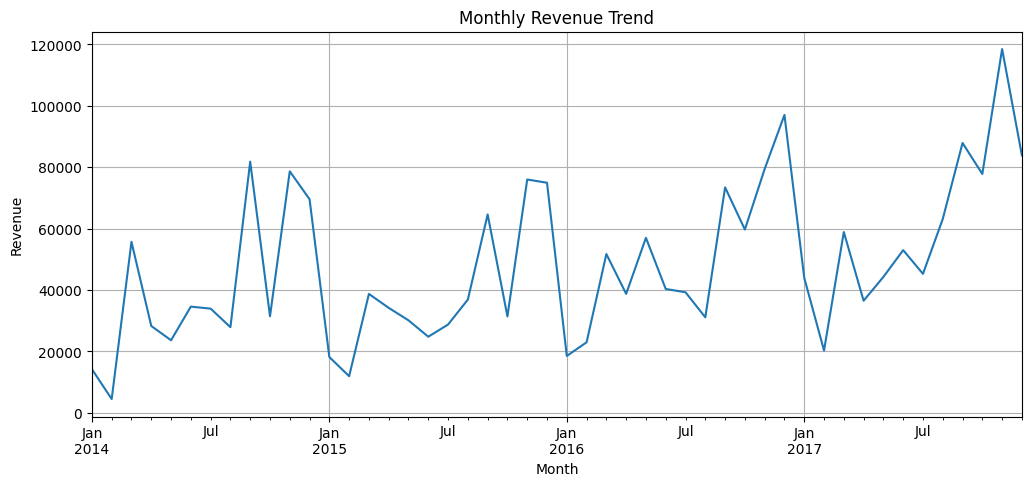

In [3]:
# ----------------------------------------------------------
# Monthly Revenue Analysis
# ----------------------------------------------------------

df["Order Date"] = pd.to_datetime(df["Order Date"])

df["Month"] = df["Order Date"].dt.to_period("M")

monthly_sales = df.groupby("Month")["Sales"].sum()

plt.figure(figsize=(12,5))

monthly_sales.plot()

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.grid(True)

plt.show()

Top 10 Products by Sales:
Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


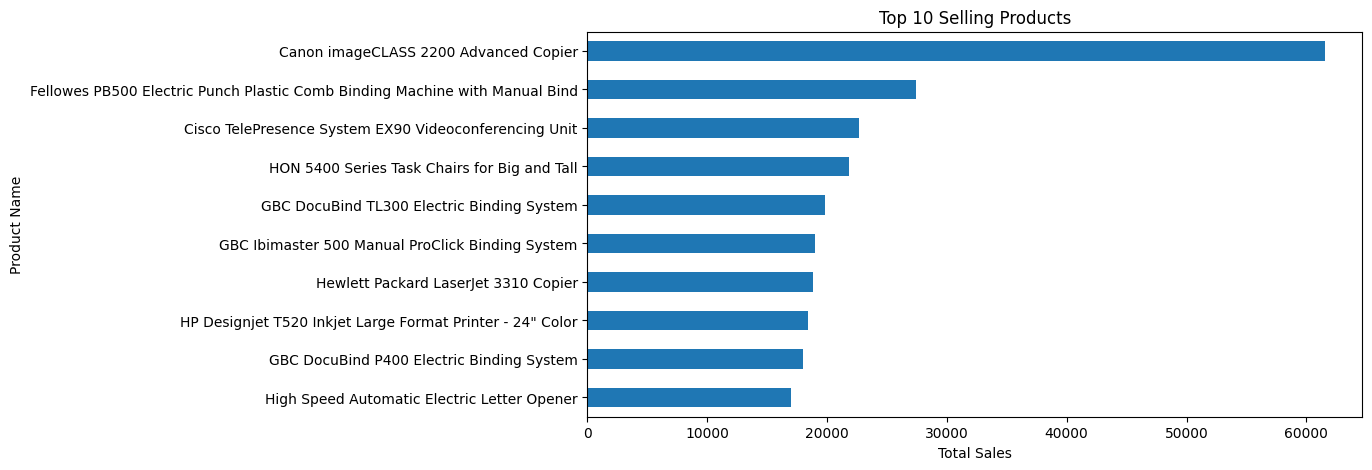

In [4]:
# ----------------------------------------------------------
# Top 10 Selling Products
# ----------------------------------------------------------

top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Products by Sales:")
print(top_products)

plt.figure(figsize=(10,5))

top_products.sort_values().plot(kind="barh")

plt.title("Top 10 Selling Products")
plt.xlabel("Total Sales")

plt.show()

Profit by Category:
Category
Technology         145454.9481
Office Supplies    122490.8008
Furniture           18451.2728
Name: Profit, dtype: float64


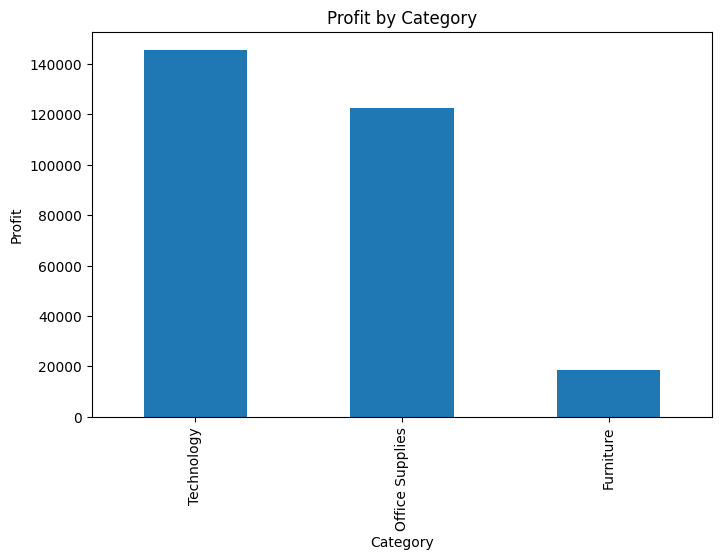


Total Sales: 2297200.86
Total Profit: 286397.02
Most Profitable Category: Technology


In [5]:
# ----------------------------------------------------------
# Profit Analysis by Category
# ----------------------------------------------------------

category_profit = (
    df.groupby("Category")["Profit"]
    .sum()
    .sort_values(ascending=False)
)

print("Profit by Category:")
print(category_profit)

plt.figure(figsize=(8,5))

category_profit.plot(kind="bar")

plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")

plt.show()


# ----------------------------------------------------------
# Final Business Insights
# ----------------------------------------------------------

print("\nTotal Sales:", round(df["Sales"].sum(), 2))
print("Total Profit:", round(df["Profit"].sum(), 2))

best_category = category_profit.idxmax()

print("Most Profitable Category:", best_category)